In [1]:
import os

# Set working directory to project root always
# Works regardless of where the notebook is saved
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    'data/healthcare/health_churn.csv'
)

print("Shape:", df.shape)
df.head()

Shape: (2000, 21)


,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PatientID                   2000 non-null   str    
 1   Age                         2000 non-null   int64  
 2   Gender                      2000 non-null   str    
 3   State                       2000 non-null   str    
 4   Tenure_Months               2000 non-null   int64  
 5   Specialty                   2000 non-null   str    
 6   Insurance_Type              2000 non-null   str    
 7   Visits_Last_Year            2000 non-null   int64  
 8   Missed_Appointments         2000 non-null   int64  
 9   Days_Since_Last_Visit       2000 non-null   int64  
 10  Last_Interaction_Date       2000 non-null   str    
 11  Overall_Satisfaction        2000 non-null   float64
 12  Wait_Time_Satisfaction      2000 non-null   float64
 13  Staff_Satisfaction          2000 non-null   

In [4]:
missing = df.isnull().sum()

print(
    missing[missing > 0]
    .sort_values(ascending=False)
)

Series([], dtype: int64)


In [5]:
print(df['Churned'].value_counts())

print(
    round(
        df['Churned']
        .value_counts(normalize=True)*100,
        2
    )
)

Churned
1    1367
0     633
Name: count, dtype: int64
Churned
1    68.35
0    31.65
Name: proportion, dtype: float64


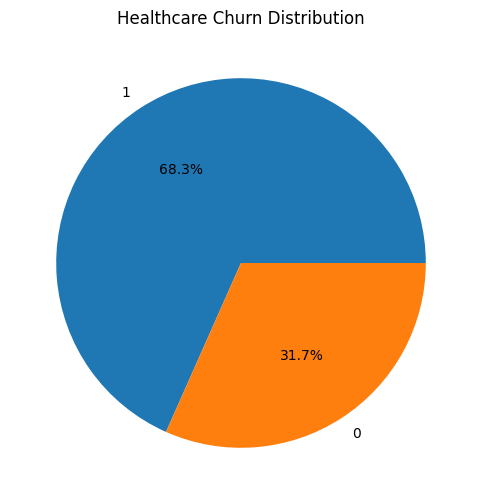

In [6]:
plt.figure(figsize=(6,6))

df['Churned'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Healthcare Churn Distribution')

plt.show()

In [7]:
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns.tolist()

num_cols.remove('Churned')

print(num_cols)

['Age', 'Tenure_Months', 'Visits_Last_Year', 'Missed_Appointments', 'Days_Since_Last_Visit', 'Overall_Satisfaction', 'Wait_Time_Satisfaction', 'Staff_Satisfaction', 'Provider_Rating', 'Avg_Out_Of_Pocket_Cost', 'Billing_Issues', 'Portal_Usage', 'Referrals_Made', 'Distance_To_Facility_Miles']


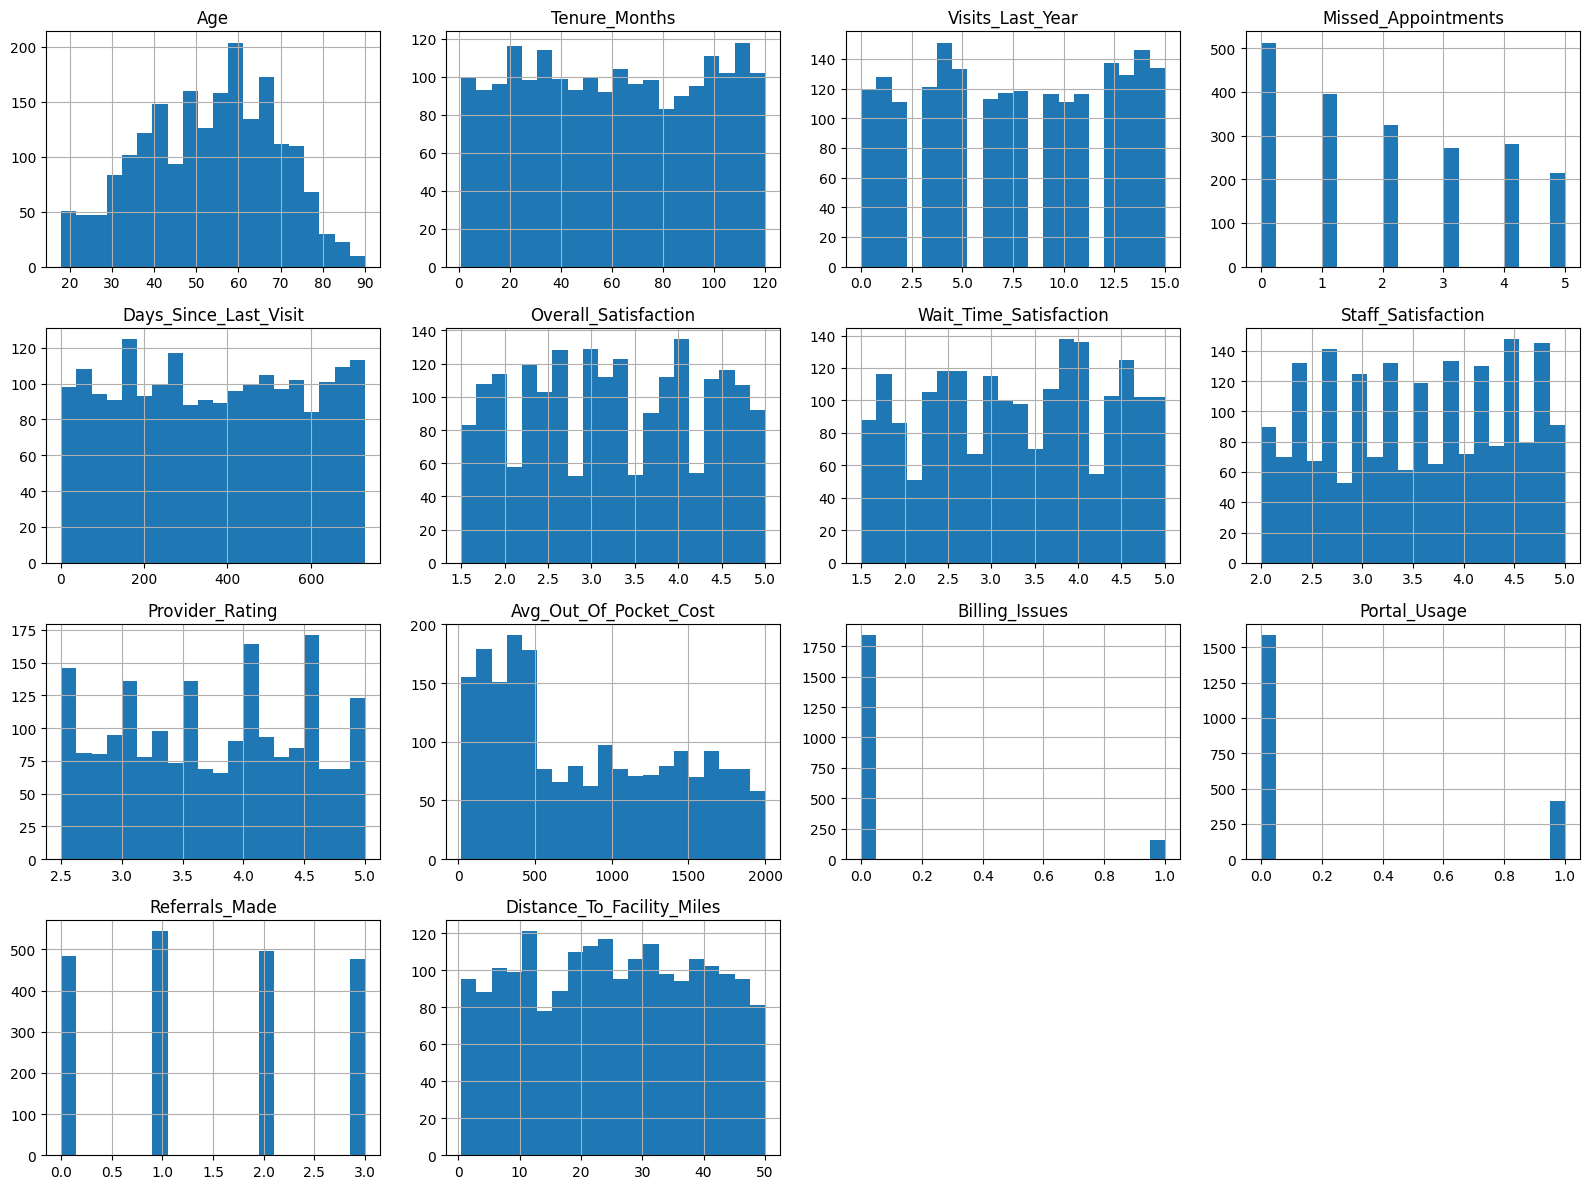

In [8]:
df[num_cols].hist(
    figsize=(16,12),
    bins=20
)

plt.tight_layout()
plt.show()

In [9]:
cat_cols = df.select_dtypes(
    include='object'
).columns.tolist()

print(cat_cols)

['PatientID', 'Gender', 'State', 'Specialty', 'Insurance_Type', 'Last_Interaction_Date']


C:\Users\DELL\AppData\Local\Temp\ipykernel_28908\1509041073.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(


In [10]:
cat_cols.remove('PatientID')
cat_cols.remove('Last_Interaction_Date')

print(cat_cols)

['Gender', 'State', 'Specialty', 'Insurance_Type']


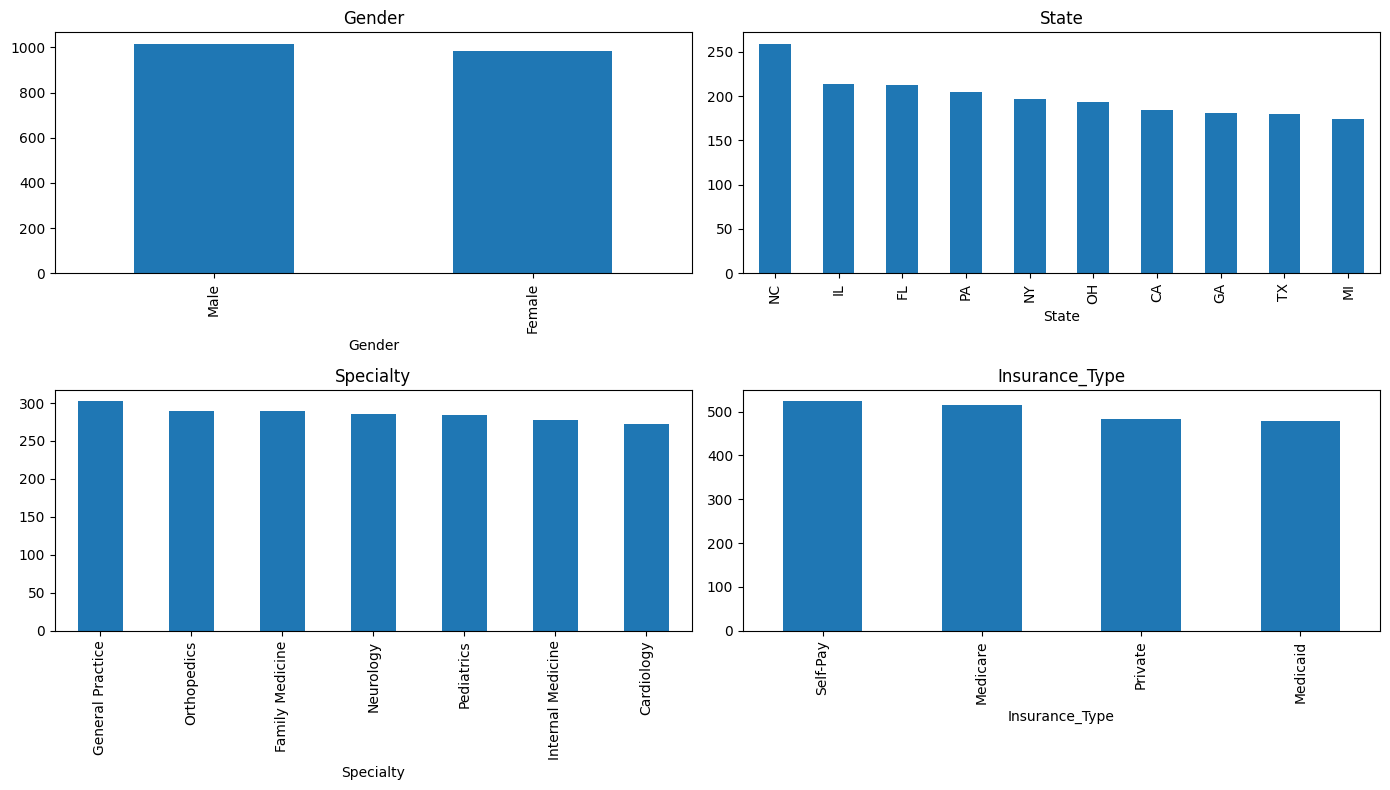

In [11]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14,8)
)

for ax, col in zip(
    axes.flatten(),
    cat_cols
):
    
    df[col].value_counts().plot(
        kind='bar',
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

In [12]:
rate = (
    df.groupby('Gender')['Churned']
    .mean()*100
)

print(rate.round(2))

Gender
Female    67.68
Male      69.00
Name: Churned, dtype: float64


In [13]:
rate = (
    df.groupby('Insurance_Type')['Churned']
    .mean()*100
)

print(rate.round(2))

Insurance_Type
Medicaid    70.50
Medicare    66.67
Private     69.36
Self-Pay    67.11
Name: Churned, dtype: float64


In [14]:
rate = (
    df.groupby('Specialty')['Churned']
    .mean()*100
)

print(
    rate.sort_values(
        ascending=False
    ).round(2)
)

Specialty
Neurology            70.28
Family Medicine      70.24
Pediatrics           69.72
General Practice     69.54
Internal Medicine    69.31
Cardiology           65.20
Orthopedics          64.01
Name: Churned, dtype: float64


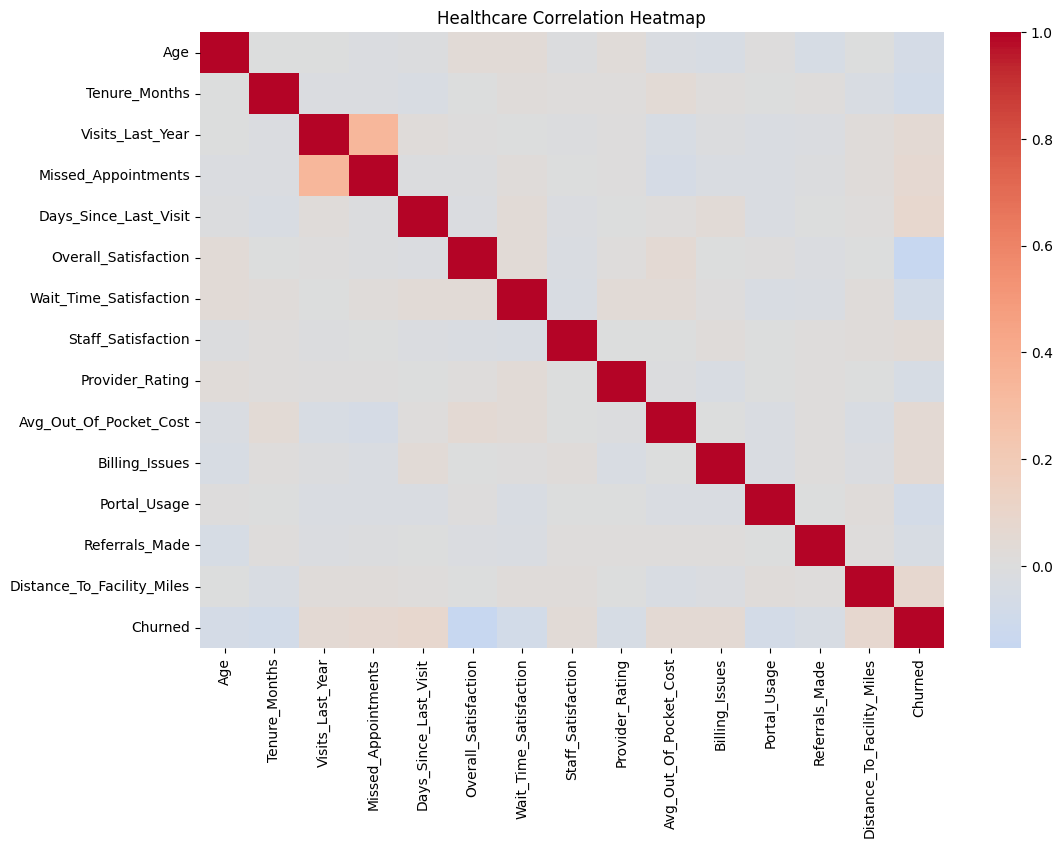

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[num_cols + ['Churned']]
    .corr(),
    cmap='coolwarm',
    center=0
)

plt.title(
    'Healthcare Correlation Heatmap'
)

plt.show()

In [16]:
corr = (
    df[num_cols + ['Churned']]
    .corr()['Churned']
    .sort_values(
        ascending=False
    )
)

print(corr)

Churned                       1.000000
Days_Since_Last_Visit         0.086291
Distance_To_Facility_Miles    0.075191
Missed_Appointments           0.069431
Avg_Out_Of_Pocket_Cost        0.056402
Billing_Issues                0.054721
Visits_Last_Year              0.051705
Staff_Satisfaction            0.031575
Referrals_Made               -0.040019
Provider_Rating              -0.054147
Age                          -0.062931
Portal_Usage                 -0.073369
Wait_Time_Satisfaction       -0.079169
Tenure_Months                -0.079738
Overall_Satisfaction         -0.153932
Name: Churned, dtype: float64


In [17]:
print(df['Churned'].value_counts())

print(
    round(
        df['Churned']
        .value_counts(normalize=True)*100,
        2
    )
)

Churned
1    1367
0     633
Name: count, dtype: int64
Churned
1    68.35
0    31.65
Name: proportion, dtype: float64


In [18]:
missing = df.isnull().sum()

print(
    missing[missing > 0]
    .sort_values(ascending=False)
)

Series([], dtype: int64)


In [19]:
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns.tolist()

corr = (
    df[num_cols]
    .corr()['Churned']
    .sort_values(ascending=False)
)

print(corr)

Churned                       1.000000
Days_Since_Last_Visit         0.086291
Distance_To_Facility_Miles    0.075191
Missed_Appointments           0.069431
Avg_Out_Of_Pocket_Cost        0.056402
Billing_Issues                0.054721
Visits_Last_Year              0.051705
Staff_Satisfaction            0.031575
Referrals_Made               -0.040019
Provider_Rating              -0.054147
Age                          -0.062931
Portal_Usage                 -0.073369
Wait_Time_Satisfaction       -0.079169
Tenure_Months                -0.079738
Overall_Satisfaction         -0.153932
Name: Churned, dtype: float64


In [20]:
rate = (
    df.groupby('Gender')['Churned']
    .mean()*100
)

print(rate.round(2))

Gender
Female    67.68
Male      69.00
Name: Churned, dtype: float64


In [21]:
rate = (
    df.groupby('Insurance_Type')['Churned']
    .mean()*100
)

print(rate.round(2))

Insurance_Type
Medicaid    70.50
Medicare    66.67
Private     69.36
Self-Pay    67.11
Name: Churned, dtype: float64


In [22]:
corr

Churned                       1.000000
Days_Since_Last_Visit         0.086291
Distance_To_Facility_Miles    0.075191
Missed_Appointments           0.069431
Avg_Out_Of_Pocket_Cost        0.056402
Billing_Issues                0.054721
Visits_Last_Year              0.051705
Staff_Satisfaction            0.031575
Referrals_Made               -0.040019
Provider_Rating              -0.054147
Age                          -0.062931
Portal_Usage                 -0.073369
Wait_Time_Satisfaction       -0.079169
Tenure_Months                -0.079738
Overall_Satisfaction         -0.153932
Name: Churned, dtype: float64

In [23]:
df.groupby('Insurance_Type')['Churned'].mean()*100

Insurance_Type
Medicaid    70.502092
Medicare    66.666667
Private     69.358178
Self-Pay    67.112811
Name: Churned, dtype: float64